Mounted at /content/drive
Device : cuda

LOADING MODEL


Loading weights:   0%|          | 0/201 [00:02<?, ?it/s]

  Loaded from /content/drive/MyDrive/PhishingClassifier/model
  Test samples : 4143

RUNNING INFERENCE
  Batch  10/130  (8%)  emails=320  phishing=162  safe=158
  Batch  20/130  (15%)  emails=640  phishing=332  safe=308
  Batch  30/130  (23%)  emails=960  phishing=484  safe=476
  Batch  40/130  (31%)  emails=1280  phishing=643  safe=637
  Batch  50/130  (38%)  emails=1600  phishing=797  safe=803
  Batch  60/130  (46%)  emails=1920  phishing=973  safe=947
  Batch  70/130  (54%)  emails=2240  phishing=1150  safe=1090
  Batch  80/130  (62%)  emails=2560  phishing=1303  safe=1257
  Batch  90/130  (69%)  emails=2880  phishing=1452  safe=1428
  Batch 100/130  (77%)  emails=3200  phishing=1607  safe=1593
  Batch 110/130  (85%)  emails=3520  phishing=1754  safe=1766
  Batch 120/130  (92%)  emails=3840  phishing=1914  safe=1926
  Batch 130/130  (100%)  emails=4143  phishing=2060  safe=2083

Inference complete.
  Total emails : 4143
  Phishing     : 2060 (49.7%)
  Safe         : 2083 (50.3%)
  A

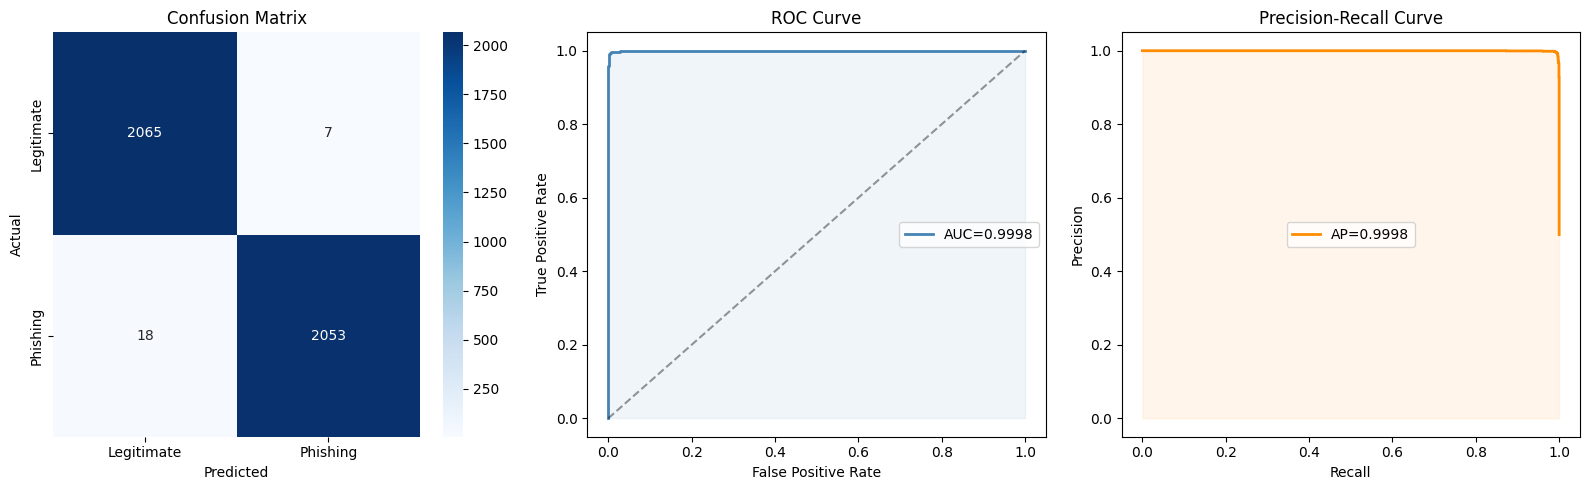

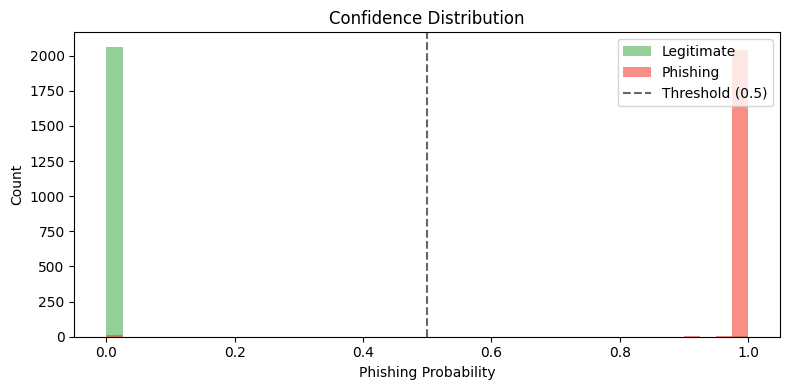


Plots saved to /content/drive/MyDrive/PhishingClassifier/plots/
Step 5 complete. Proceed to 06_inference.py


In [1]:
# ============================================================
# STEP 5 — Evaluation
# Loads best saved model, runs full evaluation on test set.
# Outputs: classification report, confusion matrix, ROC curve.
# ============================================================

import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from google.colab import drive

# ============================================================
# 5.0  Mount Drive + Folders
# ============================================================
drive.mount("/content/drive", force_remount=True)

SAVE_DIR   = "/content/drive/MyDrive/PhishingClassifier"
MAX_LEN    = 256
BATCH_SIZE = 32
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for folder in [SAVE_DIR,
               f"{SAVE_DIR}/model",
               f"{SAVE_DIR}/logs",
               f"{SAVE_DIR}/plots"]:
    os.makedirs(folder, exist_ok=True)

print(f"Device : {device}")

# ============================================================
# 5.1  Load Model
# ============================================================
print("\n" + "=" * 50)
print("LOADING MODEL")
print("=" * 50)

model     = AutoModelForSequenceClassification.from_pretrained(f"{SAVE_DIR}/model").to(device)
tokenizer = AutoTokenizer.from_pretrained(f"{SAVE_DIR}/model")
model.eval()
print(f"  Loaded from {SAVE_DIR}/model")

# ============================================================
# 5.2  Dataset + Test Loader
# ============================================================
class PhishingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = [str(t).strip() if str(t).strip() else "empty"
                          for t in texts.tolist()]
        self.labels    = [int(l) for l in labels.tolist()]
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

test_df = pd.read_csv(f"{SAVE_DIR}/test.csv")
test_df["text"]  = test_df["text"].astype(str).str.strip().fillna("empty")
test_df["label"] = pd.to_numeric(test_df["label"], errors="coerce")
test_df = test_df.dropna(subset=["text", "label"])
test_df["label"] = test_df["label"].astype(int)
test_df = test_df.reset_index(drop=True)

test_loader = DataLoader(
    PhishingDataset(test_df["text"], test_df["label"], tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
print(f"  Test samples : {len(test_df)}")

# ============================================================
# 5.3  Run Inference
# ============================================================
# ============================================================
# 5.3  Run Inference (Interactive)
# ============================================================
print("\n" + "=" * 50)
print("RUNNING INFERENCE")
print("=" * 50)

all_preds, all_labels, all_probs = [], [], []
total_batches = len(test_loader)

with torch.no_grad():
    for i, batch in enumerate(test_loader):

        # Step 1 — move batch to GPU
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        lbls = batch["label"].to(device)

        # Step 2 — forward pass (no gradient needed for inference)
        out = model(input_ids=ids, attention_mask=mask)

        # Step 3 — convert raw logits to probabilities
        # softmax turns e.g. [-1.2, 2.4] → [0.04, 0.96]
        # [:, 1] takes only the PHISHING probability
        probs = F.softmax(out.logits, dim=-1)[:, 1].cpu().numpy()

        # Step 4 — pick predicted class (0=SAFE, 1=PHISHING)
        preds = out.logits.argmax(dim=-1).cpu().numpy()

        # Step 5 — collect results across all batches
        all_preds.extend(preds)
        all_labels.extend(lbls.cpu().numpy())
        all_probs.extend(probs)

        # Progress update every 10 batches
        if (i + 1) % 10 == 0 or (i + 1) == total_batches:
            pct = (i + 1) / total_batches * 100
            phish_so_far = sum(all_preds)
            safe_so_far  = len(all_preds) - phish_so_far
            print(f"  Batch {i+1:>3}/{total_batches}  "
                  f"({pct:.0f}%)  "
                  f"emails={len(all_preds)}  "
                  f"phishing={phish_so_far}  "
                  f"safe={safe_so_far}")

print(f"\nInference complete.")
print(f"  Total emails : {len(all_preds)}")
print(f"  Phishing     : {sum(all_preds)} ({sum(all_preds)/len(all_preds)*100:.1f}%)")
print(f"  Safe         : {len(all_preds)-sum(all_preds)} ({(len(all_preds)-sum(all_preds))/len(all_preds)*100:.1f}%)")
print(f"  Avg phishing probability : {sum(all_probs)/len(all_probs):.4f}")

# ============================================================
# 5.4  Report
# ============================================================
print("\n" + "=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(all_labels, all_preds,
                             target_names=["Legitimate", "Phishing"]))
print(f"ROC-AUC           : {roc_auc_score(all_labels, all_probs):.4f}")
print(f"Average Precision : {average_precision_score(all_labels, all_probs):.4f}")

tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
print(f"\n  True Positives  (phishing caught) : {tp}")
print(f"  True Negatives  (legit passed)    : {tn}")
print(f"  False Positives (legit flagged)   : {fp}")
print(f"  False Negatives (phishing missed) : {fn}")

# ============================================================
# 5.5  Plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"],
            ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc = roc_auc_score(all_labels, all_probs)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC={auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].fill_between(fpr, tpr, alpha=0.08, color="steelblue")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)
axes[2].plot(rec, prec, color="darkorange", lw=2, label=f"AP={ap:.4f}")
axes[2].fill_between(rec, prec, alpha=0.08, color="darkorange")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/plots/evaluation.png", dpi=150)
plt.show()

# Confidence distribution
fig2, ax = plt.subplots(figsize=(8, 4))
ax.hist([p for p, l in zip(all_probs, all_labels) if l == 0],
        bins=40, alpha=0.6, color="#4CAF50", label="Legitimate")
ax.hist([p for p, l in zip(all_probs, all_labels) if l == 1],
        bins=40, alpha=0.6, color="#F44336", label="Phishing")
ax.axvline(0.5, color="black", linestyle="--", alpha=0.6, label="Threshold (0.5)")
ax.set_title("Confidence Distribution")
ax.set_xlabel("Phishing Probability")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/plots/confidence.png", dpi=150)
plt.show()

print(f"\nPlots saved to {SAVE_DIR}/plots/")
print("Step 5 complete. Proceed to 06_inference.py")